__Задание 2.__ 

Рассмотрим решение следующей граничной задачи

$$
\begin{gathered}
d^{2} y / d x^{2}=-y+x \cos x \\
\\
d y(0) / d x=3 y(0)+2, \quad d y(\pi / 2) / d x=-5 y(\pi / 2)+2 .
\end{gathered}
$$

Известно точное решение этой задачи

$$
y=-0.73 \cos x-0.441 \sin x+(1 / 4)\left(x^{2} \sin x+x \cos x\right),
$$

откуда

$$
y(\pi / 2)=0.175 \text { и } d y(\pi / 2) / d x=1.122 .
$$

Найдите эти граничные значения, решая задачу методом дифференциальной прогонки. 

In [1]:
from sympy import symbols, Eq, Function, dsolve
import sympy as sp
from IPython.display import display, Math
x, q, p, C1 = sp.symbols('x q p C1')
y = sp.Function('y')
a, b, c, g, v = sp.symbols('a b c g v', cls=Function)

# Type in your linear diff eq (De),
# and outnput is 3 differential equations on coefficients a, b, c, g
# для дифференциальной прогонки
De = y(x).diff(x, 2) + y(x) - x*sp.cos(x)
# ------------------------------------------------------------------------------------

Dyp = y(x).diff(x) - a(x)*v(x) - b(x)
Dvp = v(x).diff(x) - c(x)*y(x) - g(x)

yp = sp.solve(Dyp, y(x).diff(x))[0]
vp = sp.solve(Dvp, v(x).diff(x))[0]

ypp = sp.solve(Dyp.diff(x), y(x).diff(x, 2))[0]
ypp = ypp.subs(v(x).diff(x), vp)

Desubs = De.subs(y(x).diff(x, 2), ypp)
Desimp = sp.collect(sp.expand(Desubs), [y(x), v(x)])
E1 = Desimp.coeff(y(x))
E2 = Desimp.coeff(v(x))
E3 = Desimp - E1*y(x) - E2*v(x)
display(Desimp, E1, E2, E3)

-x*cos(x) + (a(x)*c(x) + 1)*y(x) + a(x)*g(x) + v(x)*Derivative(a(x), x) + Derivative(b(x), x)

a(x)*c(x) + 1

Derivative(a(x), x)

-x*cos(x) + a(x)*g(x) + Derivative(b(x), x)

In [2]:
# решить эти 3 уравнения и подставить выражения для a, b, c, g ниже
def a(x):
    return 1
def b(x):
    return 0
def c(x):
    return -1
def g(x):
    return x * sp.cos(x)
# ------------------------------------------------------------------------------------
# ввести начальные условия
ic1 = y(x).diff(x) - 3*y(x) - 2
ic2 = y(x).diff(x) + 5*y(x) - 2
x0 = 0; x1 = sp.pi/2
# ------------------------------------------------------------------------------------
ics = {ic1.subs(x, x0): 0, ic2.subs(x, x1): 0}

alpha, beta, v = sp.symbols('alpha beta v', cls=Function)

A = alpha(x).diff(x) + c(x)*(alpha(x))**2 - a(x)
B = beta(x).diff(x) + alpha(x)*beta(x)*c(x) + alpha(x)*g(x) - b(x)
V = v(x).diff(x) - alpha(x)*c(x)*v(x) - c(x)*beta(x) - g(x)

ysw = alpha(x)*v(x) + beta(x)
ic1_expand = ic1.subs(y(x).diff(x), a(x)*v(x) + b(x)).subs(y(x), ysw)
ic2_expand = ic2.subs(y(x).diff(x), a(x)*v(x) + b(x)).subs(y(x), ysw)

ic1Subs = ic1_expand.subs(x, x0)
ic2Subs = ic2_expand.subs(x, x1)
display("граничные условия:", sp.Eq(ic1Subs, 0), sp.Eq(ic2Subs, 0))

# решение граничных условий
alpha0, beta0 = list(sp.solve([ic1Subs.coeff(v(x).subs(x, x0)), (ic1Subs - v(0)*ic1Subs.coeff(v(x).subs(x, x0))).expand()], [alpha(x).subs(x, x0), beta(x).subs(x, x0)]).values())

alpha0, beta0

'граничные условия:'

Eq(-3*alpha(0)*v(0) - 3*beta(0) + v(0) - 2, 0)

Eq(5*alpha(pi/2)*v(pi/2) + 5*beta(pi/2) + v(pi/2) - 2, 0)

(1/3, -2/3)

In [3]:
alphax = dsolve(A, alpha(x), ics={alpha(x).subs(x, x0): alpha0}).rhs
betax = dsolve(B.subs(alpha(x), alphax), beta(x), ics={beta(x).subs(x, x0): beta0}).rhs
display(Math(r'\alpha(x)='), alphax, Math(r'\beta(x)='), betax)

<IPython.core.display.Math object>

tan(x + atan(1/3))

<IPython.core.display.Math object>

x**2*sin(x)/4 - x**2*cos(x)*tan(x + atan(1/3))/4 - x*sin(x)*tan(x + atan(1/3))/4 + x*cos(x)/4 - sqrt(10)*sqrt(tan(x + atan(1/3))**2 + 1)/5 - sin(x)/4

In [4]:
icsV = ic2Subs.subs(alpha(x).subs(x, x1), alphax.subs(x, x1)).subs(beta(x).subs(x, x1), betax.subs(x, x1))
vx1 = sp.solve(icsV, v(x).subs(x, x1))[0]
vx1 # граничное условие на v(x) справа
#dsolve(V.subs(alpha(x), alphax).subs(beta(x), betax), v(x), ics={v(x).subs(x, x1): vx1})


-53/56 + 5*pi**2/224 + 15*pi/112

-0.30537588565562235

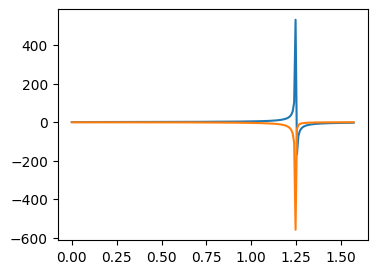

In [5]:
import numpy as np
import matplotlib.pyplot as plt
fa = sp.lambdify(x, alphax)
fb = sp.lambdify(x, betax)
xx = np.linspace(float(x0), float(x1), 200)
plt.figure(figsize=(4, 3))
plt.plot(xx, fa(xx))
plt.plot(xx, fb(xx))
float(vx1)

Text(0.5, 1.0, 'на этом промежутке решение близко к точному')

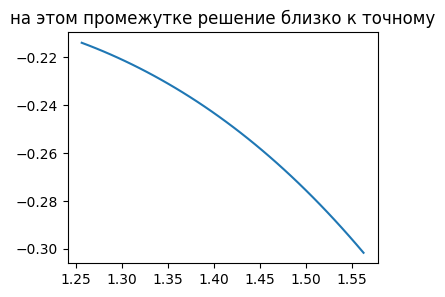

In [6]:
num_steps = 200

x0 = float(x0)
x1 = float(x1)
xx = np.linspace(x0, x1, num_steps+1)
dx = (x1 - x0)/num_steps

fa = sp.lambdify(x, alphax)
fb = sp.lambdify(x, betax)

def a(x):
    return 1
def b(x):
    return 0
def c(x):
    return -1
def g(x):
    return x * np.cos(x)

arr1 = fa(xx) * c(xx)
arr2 = fb(xx) * c(xx) + g(xx)

v = np.zeros(num_steps+1)
v[-1] = float(vx1)
for k in range(num_steps-1, -1, -1):
    v[k] = v[k+1] - dx*(arr1[k+1]*v[k+1] + arr2[k+1])

plt.figure(figsize=(4,3))
plt.plot(xx[160:-1], v[160:-1])
plt.title('на этом промежутке решение близко к точному')



In [7]:
alpha1 = alphax.subs(x, x1)
beta1 = betax.subs(x, x1)
y1 = alpha1*vx1 + beta1
float(y1)

0.4610751771311246

0.4610751771311241

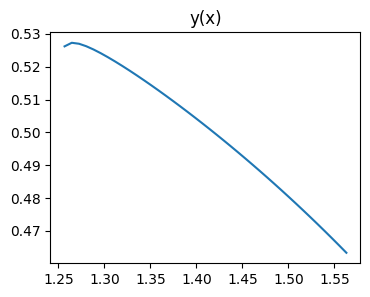

In [8]:
plt.figure(figsize=(4,3))
y = fa(xx)*v + fb(xx)
plt.plot(xx[160:-1], y[160:-1])
plt.title('y(x)')
y[-1]

In [9]:
ypr = (y[-1] - y[-3])/(2*dx)
display(Math(r'y_x(\pi/2)='), ypr)

<IPython.core.display.Math object>

-0.28639516832385076

In [15]:
 #eqs = [Eq(E1, 0), Eq(E2, 0)]
 #sp.dsolve(E2, a(x))
 #sp.dsolve(E1.subs(a(x), C1), c(x))
 #sp.dsolve([E1, E2], [a(x), c(x)])
 #sp.dsolve([E1, E2, E3], [a(x), b(x), c(x)])